### Importy

In [1]:
import pandas as pd                                                                                                       
import numpy as np                                                                                                        
import matplotlib.pyplot as plt                                                                                           
import seaborn as sns                                                                                                     
from sklearn.cluster import KMeans                                                                                        
from sklearn.metrics import silhouette_score                                                                              
from sklearn.metrics.cluster import contingency_matrix                                                                    

In [2]:
df = pd.read_csv('Dry_Bean_preprocessed.csv')                                                                             
X = df.drop(columns=['Class'])                                                                                            
y = df['Class']                                                                                                           

### Algorytm K-Means

In [3]:
def purity_score(labels_true, labels_pred):                                                                               
    cont_matrix = contingency_matrix(labels_true, labels_pred)                                                            
    max_per_cluster = np.max(cont_matrix, axis=0)                                                                         
    return np.sum(max_per_cluster) / np.sum(cont_matrix)                                                                  

In [6]:
inertions = []
silhouette_res = []
purity_res = []

for k in range(2,12):
    kmeans = KMeans(n_clusters=k, random_state = 67)
    kmeans.fit(X)
    initial_clusters = kmeans.labels_
    inertions.append(kmeans.inertia_)
    sil = silhouette_score(X, initial_clusters)
    silhouette_res.append(sil)
    pur = purity_score(y, initial_clusters)
    purity_res.append(pur)



### Wizualizacje metryk uzyskanych w KMEANS

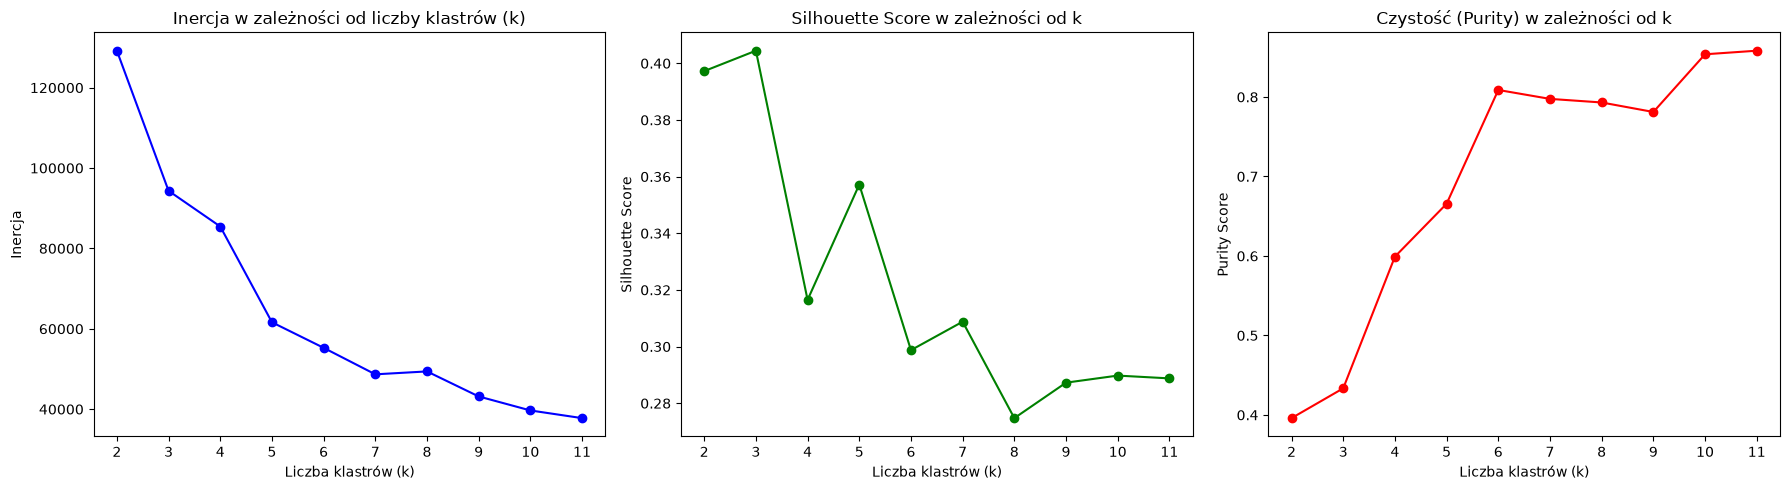

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))                                                                           
axes[0].plot(range(2,12), inertions, marker='o', linestyle='-', color='b')                                                     
axes[0].set_title('Inercja w zależności od liczby klastrów (k)')                                                          
axes[0].set_xlabel('Liczba klastrów (k)')                                                                                 
axes[0].set_ylabel('Inercja')                                                                                      
axes[0].set_xticks(range(2,12))                                                                                              
                                                                                                                                                                                                      
axes[1].plot(range(2,12), silhouette_res, marker='o', linestyle='-', color='g')                                           
axes[1].set_title('Silhouette Score w zależności od k')                                                                   
axes[1].set_xlabel('Liczba klastrów (k)')                                                                                 
axes[1].set_ylabel('Silhouette Score')                                                                                    
axes[1].set_xticks(range(2,12))                                                                                              
                                                                                                                                                                                                      
axes[2].plot(range(2,12), purity_res, marker='o', linestyle='-', color='r')                                               
axes[2].set_title('Czystość (Purity) w zależności od k')                                                                  
axes[2].set_xlabel('Liczba klastrów (k)')                                                                                 
axes[2].set_ylabel('Purity Score')                                                                                        
axes[2].set_xticks(range(2,12))                                                                                              
                                                                                                                                                                                         
plt.tight_layout()                                                                                                        
plt.show()                                                                                                                

Inercja - oblicza środek każdego klastra, a potem mierzy odległość każdego punktu do tego środka. Inercja
to suma tych wszystkich odległości. Im mniejsza, tym klastry są bardziej zbite.

Silhouette Score - oblicza proporcję: jak blisko jest dany wierzochołek od innych w klastrze przez jak daleko ma do obcych z
najbliższego sąsiedniego klastra. Wynik bliski 1 to ideał (jesteśmy odizolowaną, zbitą grupą), 0 to pogranicze, wartości
ujemne to błąd przypisania.

Purity - co mierzy: to sprawdzenie z kluczem odpowiedzi. Bierze klaster, patrzy jaki gatunek fasoli w nim dominuje (np. 80% to
Dermason) i uznaje te 80% za "czyste" dopasowanie, a resztę za błędy.



- Jeśli chodzi o inercję, to spadek największy występuje przy k = 2, ale elbow_k to 5, po nim następuje wypłaszczenie, ewentualnie można jeszce k = 7 uznać za elbow_k. 
- W wykresie Silhouette Score najwyżej jest w k = 3, potem wzrost jest też przy k = 5 i k = 7.
- W wykresie Purity to k = 6 i k = 10 się wyróżniają. Od k = 7 do k = 9 jest stabilny spadek.

- Biorąć pod uwagę te 3 miary wybieram jako KOMPROMIS k = 7, bo aż 3 razy się powtarza jako wyróżniony punkt.

- Optymalne k nie istnieje , bo różne metryki wskazują na różne cechy rozkładu, trzeab szukać kompromisu.

### Wizualizacja wyników

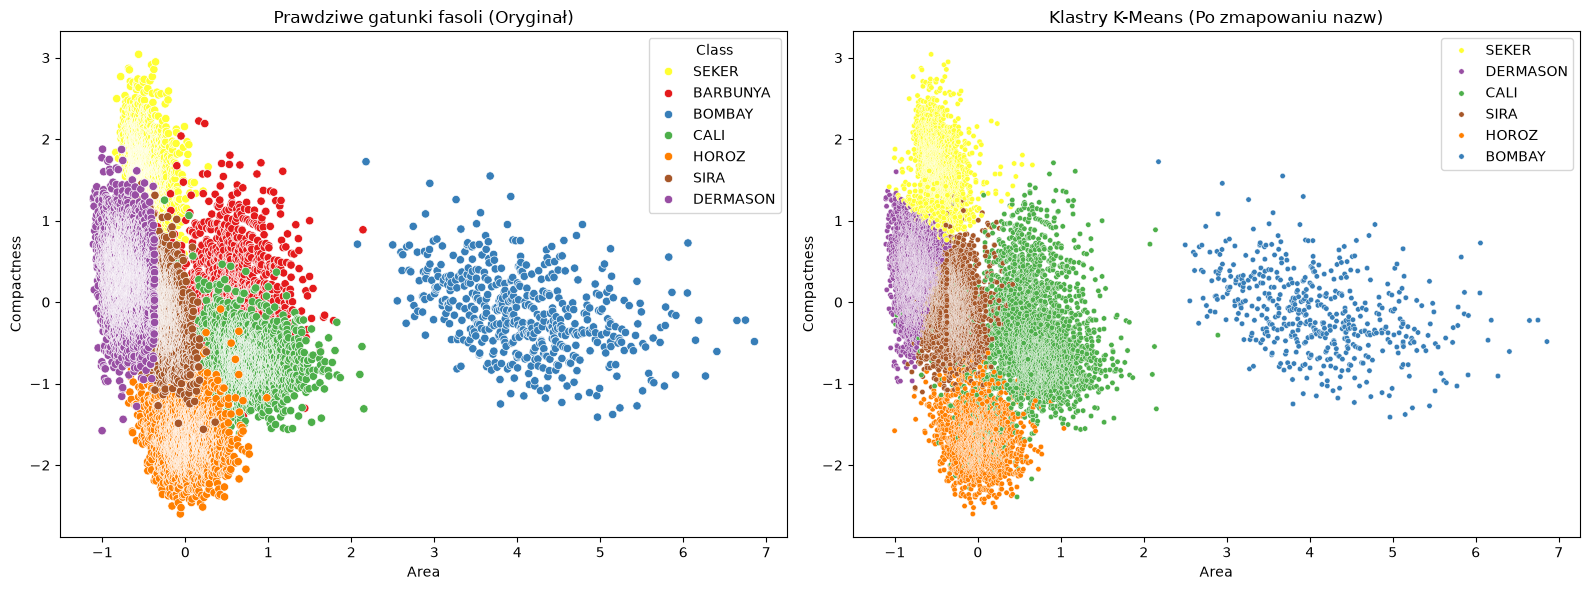

In [11]:
final_kmeans = KMeans(n_clusters=7, random_state = 67)                                                                      
final_kmeans.fit(X)                                                                                                       
predicted_clusters = final_kmeans.labels_                                                                                 
                                                                                                                                                                                  
mapped_labels = np.empty_like(predicted_clusters, dtype=object)                                                           
for i in range(7):                                                                                                        
    mask = (predicted_clusters == i)                                                                                                                                                 
    common_class = df.loc[mask, 'Class'].mode()[0]                                                                                                                                                  
    mapped_labels[mask] = common_class                                                                              
                                                                                                                                                                                                 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))                                                                           
                                                                                                                                                        
unique_classes = sorted(df['Class'].unique())                                                                             
common_pallette = dict(zip(unique_classes, sns.color_palette("Set1", len(unique_classes))))                                
                                                                                                                                                                                                     
sns.scatterplot(data=df, x='Area', y='Compactness', hue='Class', palette=common_pallette, ax=axes[0])                                                                 
axes[0].set_title('Prawdziwe gatunki fasoli (Oryginał)')                                                                  
sns.scatterplot(data=df, x='Area', y='Compactness', hue=mapped_labels, palette=common_pallette, ax=axes[1], s=15)                                                                 
axes[1].set_title('Klastry K-Means (Po zmapowaniu nazw)')                                                                 
                                                                                                                              
plt.tight_layout()                                                                                                        
plt.show()                                                                                                                                                                                                                                             

- Wykres dobrze odwzorowuje orginał poza faktem, że kolor zielony prawie całkowicie pochłonął kolor czerwony.

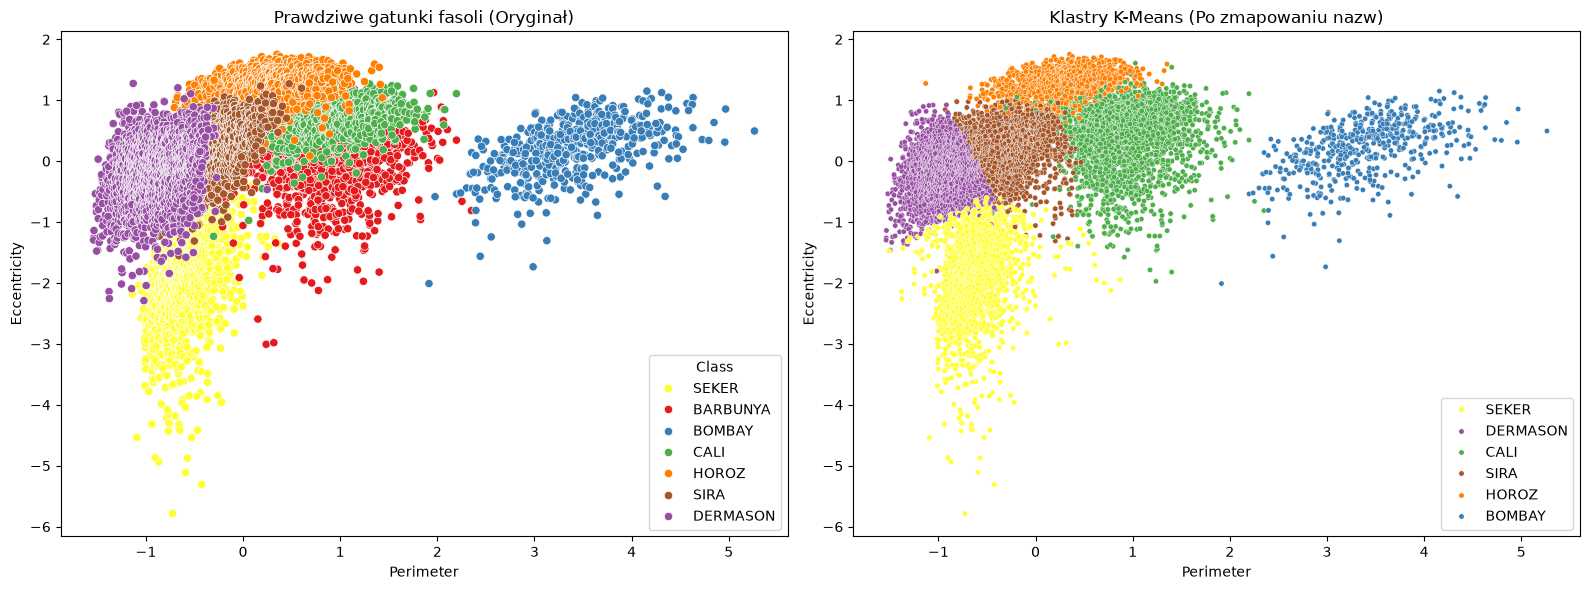

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))                                                                                                         
                                                                                                                                                                                                     
sns.scatterplot(data=df, x='Perimeter', y='Eccentricity', hue='Class', palette=common_pallette, ax=axes[0])                                                                 
axes[0].set_title('Prawdziwe gatunki fasoli (Oryginał)')                                                                  
sns.scatterplot(data=df, x='Perimeter', y='Eccentricity', hue=mapped_labels, palette=common_pallette, ax=axes[1], s=15)                                                                 
axes[1].set_title('Klastry K-Means (Po zmapowaniu nazw)')                                                                 
                                                                                                                              
plt.tight_layout()                                                                                                        
plt.show()    

- Ponownie kolor zielony pochłonął czerwony. Tutaj dodatkowo brązowy umocnił się kosztem fioletowego.